In [3]:
import pandas as pd
import numpy as np
from os import listdir
import torch
import torchaudio
import matplotlib.pyplot as plt

In [79]:
def loadDataAsSpectrogram(path:str)->dict[str:np.ndarray]:
    return {file:torchaudio.transforms.AmplitudeToDB()(torchaudio.transforms.Spectrogram()(torchaudio.load(path+file)[0]))[0] for file in listdir(path) if file.endswith('.wav')}

In [80]:
data = loadDataAsSpectrogram('.././data/audios_development/')

In [130]:
data['3.wav'].shape

torch.Size([201, 4778])

In [131]:
length = {key:data[key].shape[1] for key in data}

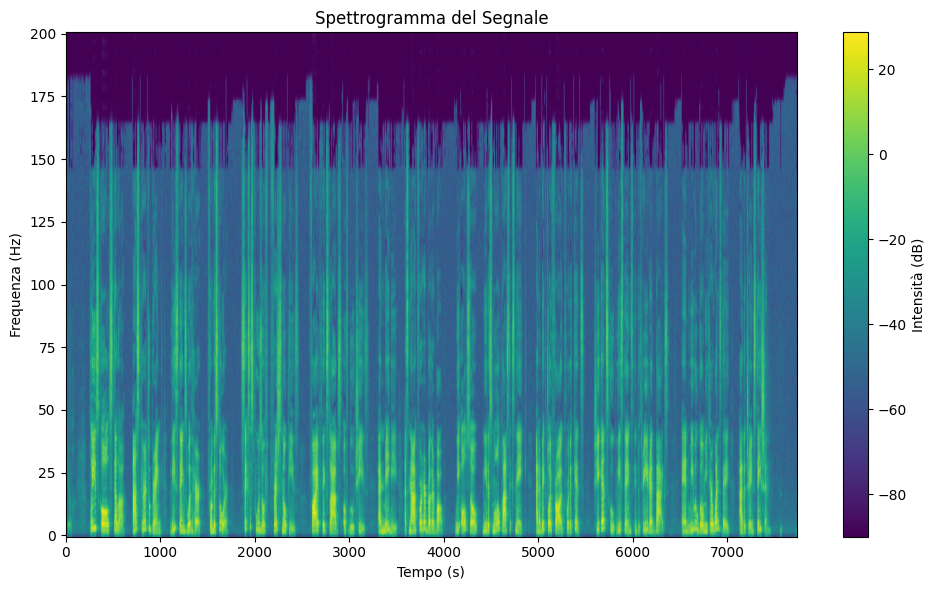

In [82]:
# Caricamento del file audio
waveform, sample_rate = torchaudio.load('.././data/audios_development/1.wav')

# Calcolo dello spettrogramma
spectrogram_transform = torchaudio.transforms.Spectrogram(n_fft=400)
spectrogram = spectrogram_transform(waveform)

# Conversione dello spettrogramma in dB
spectrogram_db = 10 * torch.log10(spectrogram + 1e-9)

# Visualizzazione dello spettrogramma
plt.figure(figsize=(10, 6))
plt.imshow(spectrogram_db[0].numpy(), cmap='viridis', origin='lower', aspect='auto')
plt.colorbar(label='Intensità (dB)')
plt.ylabel('Frequenza (Hz)')
plt.xlabel('Tempo (s)')
plt.title('Spettrogramma del Segnale')
plt.tight_layout()
plt.show()


In [83]:
def createSubMatrix(data:np.ndarray, rows:int, cols:int)->dict[str:np.ndarray]:
    return ({key:np.array([data[key][data[key].shape[0]//rows * i: min(data[key].shape[0]//rows * (i+1), data[key].shape[0]), data[key].shape[1]//cols * j: min(data[key].shape[1]//cols * (j+1), data[key].shape[1])].mean() for i in range(rows) for j in range(cols)]) for key in data},
            {key:np.array([data[key][data[key].shape[0]//rows * i: min(data[key].shape[0]//rows * (i+1), data[key].shape[0]), data[key].shape[1]//cols * j: min(data[key].shape[1]//cols * (j+1), data[key].shape[1])].std() for i in range(rows) for j in range(cols)]) for key in data})

In [84]:
row =4
col=4
prova = createSubMatrix(data, row, col)

In [85]:
mean, std = pd.DataFrame(prova[0], index=[f'mean{i}' for i in range(0,row*col) ]).T, pd.DataFrame(prova[1], index=[f'std{i}' for i in range(0,row*col)]).T

In [4]:
# from sklearn.metrics import
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

temp = pd.read_csv('.././data/development.csv', index_col=0)

temp['tempo'] = temp['tempo'].map(lambda x:x[1:-1]).astype(np.float32)
temp['gender'] = temp['gender'].map(lambda x: 0 if x.lower() == 'male' else 1)
age = temp['age']

temp['path'] = temp['path'].map(lambda x: x.split('/')[-1])
temp

,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path
Id,,,,,,,,,,,,,,,,,,,
0,22050,24.0,1,arabic,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,151.999084,-123.999726,69,281,39,23.846893,1.wav
1,22050,22.5,1,hungarian,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,129.199219,-86.928478,69,281,21,19.388662,2.wav
2,22050,22.0,1,portuguese,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,117.453835,-98.450670,69,281,1,21.640998,3.wav
3,22050,22.0,1,english,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,117.453835,-56.459762,69,281,9,19.644127,4.wav
4,22050,22.0,0,dutch,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,112.347145,-80.349204,69,281,11,18.041905,5.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,22050,24.0,0,english,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,184.570312,-100.921055,69,281,11,17.461406,2929.wav
2929,22050,15.0,1,igbo,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,83.354332,6.757283,0,0,1,1.509206,2930.wav
2930,22050,17.0,1,igbo,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,89.102913,-53.913449,1,9,1,1.645034,2931.wav


In [6]:
dataTensor = {file:torchaudio.load('.././data/audios_development/'+file)[0][0] for file in listdir('.././data/audios_development/') if file.endswith('.wav')}

In [88]:
def calculate_spectral_features_torchaudio(audio, sampling_rate):
    # Compute the magnitude spectrogram
    spectrogram = torch.stft(audio, n_fft=2048, return_complex=True)
    magnitude_spectrum = torch.abs(spectrogram).mean(dim=1)
    
    # Frequencies corresponding to FFT bins
    freqs = torch.linspace(0, sampling_rate / 2, magnitude_spectrum.size(0))
    
    # Spectral Centroid
    spectral_centroid = torch.sum(freqs * magnitude_spectrum) / torch.sum(magnitude_spectrum)
    
    # Spectral Bandwidth
    spectral_bandwidth = torch.sqrt(torch.sum(((freqs - spectral_centroid)**2) * magnitude_spectrum) / torch.sum(magnitude_spectrum))
    
    # Spectral Rolloff
    cumulative_spectrum = torch.cumsum(magnitude_spectrum, dim=0)
    rolloff_threshold = 0.85 * cumulative_spectrum[-1]
    spectral_rolloff = freqs[torch.where(cumulative_spectrum >= rolloff_threshold)[0][0]]
    
    return spectral_centroid.item(), spectral_bandwidth.item(), spectral_rolloff.item()

In [89]:
additoonal = pd.DataFrame({file:calculate_spectral_features_torchaudio(dataTensor[file], 22050) for file in dataTensor}, index=['spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff']).T

In [90]:
def extract_f0_std_torchaudio_manual(audio_tensor, sampling_rate, frame_size=2048, hop_size=512):
    # Convert audio to tensor
    if audio_tensor.dim() > 1:  # Se stereo, usa un solo canale
        audio_tensor = audio_tensor.mean(dim=0)
    
    # Elenco dei valori F0
    f0_values = []
    
    # Scorriamo il segnale audio in finestre
    for start in range(0, len(audio_tensor) - frame_size, hop_size):
        frame = audio_tensor[start:start + frame_size]
        if frame.abs().sum() == 0:  # Salta finestre silenziose
            continue
        
        # FFT e calcolo dello spettro
        spectrum = torch.fft.fft(frame)
        magnitudes = torch.abs(spectrum[:frame_size // 2])  # Prendi la metà positiva
        frequencies = torch.linspace(0, sampling_rate / 2, frame_size // 2)
        
        # Trova il picco fondamentale
        peak_index = torch.argmax(magnitudes)
        f0 = frequencies[peak_index]
        
        # Ignora valori non validi o troppo bassi
        if f0 > 50:  # Filtro per valori realistici
            f0_values.append(f0.item())
    
    # Calcolo della media e deviazione standard
    f0_values = np.array(f0_values)
    f0_mean = np.mean(f0_values) if len(f0_values) > 0 else 0
    f0_std = np.std(f0_values) if len(f0_values) > 0 else 0
    
    return f0_mean, f0_std

In [91]:
f0 = pd.DataFrame({file:extract_f0_std_torchaudio_manual(dataTensor[file], 22050)
                   for file in dataTensor}, index=['f0_mean', 'f0_std']).T

In [95]:
spect = pd.DataFrame({file: torchaudio.transforms.MFCC(
    sample_rate=22050,
    n_mfcc=23,
    melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 23, "center": False},
)(dataTensor[file]).mean(axis=1) for file in dataTensor}, index=[f'mfcc{i}' for i in range(0,23)]).T

In [144]:
newSpect = (pd.concat([ spect.iloc[:, 0:6].mean(axis=1), spect.iloc[:, 6:12].mean(axis=1), 
                      spect.iloc[:, 12:18].mean(axis=1), spect.iloc[:, 18:].mean(axis=1),
                      spect.iloc[:, 0:6].std(axis=1), spect.iloc[:, 6:12].std(axis=1), 
                      spect.iloc[:, 12:18].std(axis=1), spect.iloc[:, 18:].std(axis=1)], axis=1)
            .rename(columns={0:'mfcc1-6', 1:'mfcc7-12', 2:'mfcc13-18', 3:'mfcc19-23', 
                             4:'mfcc1-6_std', 5:'mfcc7-12_std', 6:'mfcc13-18_std', 7:'mfcc19-23_std'}))

In [150]:
temp = temp.set_index(temp['path'])

temp = pd.concat([temp.sort_index(), newSpect.sort_index()], axis=1)

In [178]:
temptemp = temp[temp['path']!='1017.wav']

In [180]:
dfMan, dfWoman = temptemp[temptemp['gender']==0], temptemp[temptemp['gender']==1]
ageMan, ageWoman = dfMan['age'], dfWoman['age']

In [181]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor

remove = ['age', 'sampling_rate', 'ethnicity', 'path']
clf = RandomForestRegressor(n_jobs=-1)

clf.fit(temp.drop(columns=remove), age)




(cross_val_score(RandomForestRegressor(n_jobs=-1), dfMan.drop(columns=remove), ageMan, cv=15, scoring='neg_root_mean_squared_error').mean()+
cross_val_score(RandomForestRegressor(n_jobs=-1), dfWoman.drop(columns=remove), ageWoman, cv=15, scoring='neg_root_mean_squared_error').mean())/2

np.float64(-10.836064845672617)

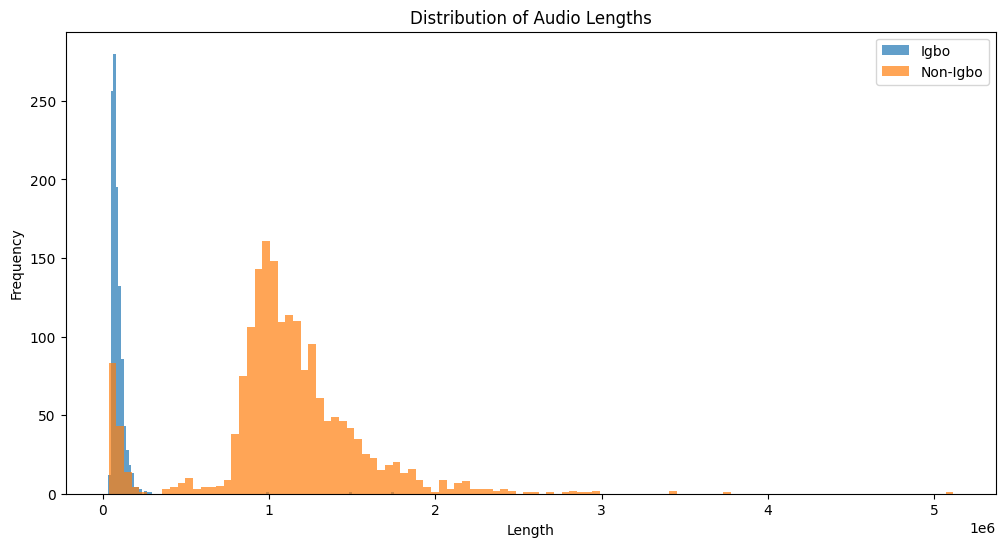

In [182]:
lunghezzaIgbo = np.array([dataTensor[key].shape[0] for key in temp[temp['ethnicity']=='igbo']['path']])
lunghezzaNonIgbo = np.array([dataTensor[key].shape[0] for key in temp[~(temp['ethnicity']=='igbo')]['path']])
plt.figure(figsize=(12, 6))
plt.hist(lunghezzaIgbo, bins=110, alpha=0.7, label='Igbo')
plt.hist(lunghezzaNonIgbo, bins=110, alpha=0.7, label='Non-Igbo')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('Distribution of Audio Lengths')
plt.legend()
plt.show()

In [175]:
temp[~(temp['ethnicity']=='igbo')].iloc[618:620, :]

,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path
Id,,,,,,,,,,,,,,,,,,,
1015,22050,23.0,1,arabic,1887.1305,3999.7317,145.36224,0.015309,0.073789,0.006480,0.199202,2702.411803,107.666016,-106.390264,69,281,34,17.089887,1016.wav
1016,22050,86.0,1,hungarian,1880.8478,3999.7612,145.44034,0.024327,0.142816,0.011508,0.237755,3527.355886,135.999176,-80.149970,69,281,84,83.777596,1017.wav


np.float64(0.08201701597832485)

In [153]:
for v,k in sorted(zip(clf.feature_importances_, temp.drop(columns=remove).columns), key=lambda x:x[0], reverse=True):
    print(f'{k}: {v*100}')

jitter: 5.084604955829341
mean_pitch: 4.89706434622362
shimmer: 4.746481066244177
max_pitch: 4.712915894210883
min_pitch: 4.704980815465433
hnr: 4.562658789674442
spectral_centroid_mean: 4.538112899286952
energy: 4.121558122333748
tempo: 4.112394514056248
silence_duration: 4.042188340974746
zcr_mean: 3.9322969104568797
mfcc13-18: 3.3950738485143885
mfcc19-23_std: 3.346907637553604
mfcc7-12_std: 3.323777131084192
mfcc7-12_std: 3.3164996396607727
mfcc19-23_std: 3.2801975550477516
mfcc13-18: 3.2596957046089843
mfcc19-23: 3.15741208048803
mfcc19-23: 3.1268707181939144
mfcc7-12: 2.9536925892763697
mfcc7-12: 2.8954996902377403
mfcc13-18_std: 2.736940990658484
mfcc1-6_std: 2.7298413120179004
mfcc1-6_std: 2.554688904595473
mfcc13-18_std: 2.495001391192347
mfcc1-6: 2.2547614779538545
num_pauses: 2.1616966049419912
mfcc1-6: 2.0840384841387123
num_characters: 0.6332133425185854
num_words: 0.4472681666857609
gender: 0.3916660758746568


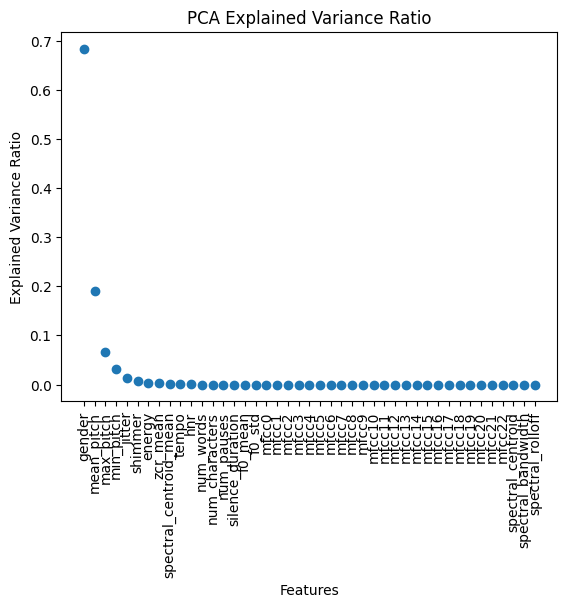

In [119]:
from sklearn.decomposition import PCA

pca = PCA(n_components=temp.drop(columns=remove).shape[1])
pca_result = pca.fit(temp.drop(columns=remove)).explained_variance_ratio_

pca_df = pd.DataFrame(pca_result, index=temp.drop(columns=remove).columns, columns=['explained_variance_ratio'])
plt.scatter(pca_df.index, pca_df['explained_variance_ratio'])
plt.xlabel('Features')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.xticks(rotation=90)
plt.show()

In [122]:
for i in range(3, 10):
    print(i, cross_val_score(RandomForestRegressor(n_jobs=-1), PCA(n_components=i).fit_transform(temp.drop(columns=remove)),
                age, cv=15, scoring='neg_root_mean_squared_error').mean())

3 -13.932078290506157
4 -13.62161199346996
5 -13.405543645336731
6 -13.440913734399365
7 -13.370418944594224
8 -13.40384173717668
9 -13.418977171277389


In [124]:
df = pd.read_csv('.././data/development.csv', index_col=0)

df['tempo'] = df['tempo'].map(lambda x:x[1:-1]).astype(np.float32)
df['gender'] = df['gender'].map(lambda x: 0 if x.lower() == 'male' else 1)
age = df['age']
df = df.drop(columns=['age', 'sampling_rate', 'ethnicity', 'path'])

for i in range(3, df.shape[1]):
    print(i, cross_val_score(RandomForestRegressor(n_jobs=-1), PCA(n_components=i).fit_transform(df),
                age, cv=15, scoring='neg_root_mean_squared_error').mean())

3 -12.749116087293427
4 -12.053190660428212
5 -11.791810033952158
6 -11.809981028945124
7 -11.59151748292177
8 -11.32271193250882
9 -11.325876144990145
10 -11.191846101698177
11 -11.260524718866183
12 -11.047247467239323
13 -10.91373375208216
14 -10.908940163624427


In [7]:
nationality = temp[temp['path'].isin([key for key in dataTensor if dataTensor[key].shape[0] < 300000])]['ethnicity'].unique()


In [8]:
nationality

array(['igbo', 'urhobo', 'igala', 'ibibio', 'congolese', 'ijaw', 'yoruba',
       'ika', 'afemai', 'ikwerre', 'obudu', 'kaire-kaire', 'ukwani',
       'tiv', 'hausa', 'annang', 'indian', 'cameroonian'], dtype=object)

In [9]:
dfAfrica, dfNonAfrica = temp[temp['ethnicity'].isin(nationality)], temp[~temp['ethnicity'].isin(nationality)]

In [10]:
from sklearn.neural_network import MLPRegressor
rfAfrica = RandomForestRegressor(n_jobs=-1)
rfNAfrica = RandomForestRegressor(n_jobs=-1)

scoreAfrica = cross_val_score(rfAfrica, dfAfrica.drop(columns=remove), dfAfrica['age'], cv=15, scoring='neg_root_mean_squared_error').mean()
scoreNonAfrica = cross_val_score(rfNAfrica, dfNonAfrica.drop(columns=remove), dfNonAfrica['age'], cv=15, scoring='neg_root_mean_squared_error').mean()

print('Africa:', scoreAfrica)
print('Non-Africa:', scoreNonAfrica)
print('Average:', (scoreAfrica*dfAfrica.shape[0] + scoreNonAfrica*dfNonAfrica.shape[0]) / (dfAfrica.shape[0] + dfNonAfrica.shape[0]))

NameError: name 'cross_val_score' is not defined

In [203]:
dfManAfrica, dfWomanAfrica = dfAfrica[dfAfrica['gender']==0], dfAfrica[dfAfrica['gender']==1]
# ageManAfrica, ageWomanAfrica = dfManAfrica['age'], dfWomanAfrica['age']

dfManNonAfrica, dfWomanNonAfrica = dfNonAfrica[dfNonAfrica['gender']==0], dfNonAfrica[dfNonAfrica['gender']==1]

In [204]:
AfricaManScore = cross_val_score(RandomForestRegressor(n_jobs=-1), dfManAfrica.drop(columns=remove), dfManAfrica['age'], cv=15, scoring='neg_root_mean_squared_error').mean()
AfricaWomanScore = cross_val_score(RandomForestRegressor(n_jobs=-1), dfWomanAfrica.drop(columns=remove), dfWomanAfrica['age'], cv=15, scoring='neg_root_mean_squared_error').mean()
nonAfricanManScore = cross_val_score(RandomForestRegressor(n_jobs=-1), dfManNonAfrica.drop(columns=remove), dfManNonAfrica['age'], cv=15, scoring='neg_root_mean_squared_error').mean()
nonAfricanWomanScore = cross_val_score(RandomForestRegressor(n_jobs=-1), dfWomanNonAfrica.drop(columns=remove), dfWomanNonAfrica['age'], cv=15, scoring='neg_root_mean_squared_error').mean()

print('Africa Man :', AfricaManScore)
print('Africa Woman :', AfricaWomanScore)
print('Non Africa Man :', nonAfricanManScore)
print('Non Africa Woman :', nonAfricanWomanScore)
africa_weight = dfManAfrica.shape[0] + dfWomanAfrica.shape[0]
non_africa_weight = dfManNonAfrica.shape[0] + dfWomanNonAfrica.shape[0]
total_weight = africa_weight + non_africa_weight

weighted_average = ((AfricaManScore * dfManAfrica.shape[0] + AfricaWomanScore * dfWomanAfrica.shape[0] +
                     nonAfricanManScore * dfManNonAfrica.shape[0] + nonAfricanWomanScore * dfWomanNonAfrica.shape[0]) / total_weight)

print('Average Africa:', (AfricaManScore + AfricaWomanScore) / 2)
print('Average Non Africa:', (nonAfricanManScore + nonAfricanWomanScore) / 2)
print('Average:', (AfricaManScore + AfricaWomanScore + nonAfricanManScore + nonAfricanWomanScore) / 4)
print('Weighted Average:', weighted_average)

Africa Man : -5.602250945407472
Africa Woman : -4.343506561290778
Non Africa Man : -13.095710027515686
Non Africa Woman : -14.109389218115265
Average Africa: -4.972878753349125
Average Non Africa: -13.602549622815475
Average: -9.287714188082301
Weighted Average: -9.941946082615464


In [1]:
import seaborn as sns
plt.figure(figsize=(12, 12))
sns.heatmap(dfAfrica.corr(method='spearman'), annot=True, fmt=".2f", cmap='coolwarm')

NameError: name 'plt' is not defined